In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
results_path = "../results"
ppm_res = pd.read_csv(f"{results_path}/planner_comp_results_all_detailed.csv")
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'axes.titlesize': 16, 'xtick.labelsize': 12, 'ytick.labelsize': 12})
figsize = (6, 4)

In [13]:
indices = ppm_res[ppm_res['heuristic'] == 'MIXED_G'].index
ppm_res.loc[indices, 'heuristic'] = 'MULTI_BOUND'
ppm_res.loc[ppm_res['heuristic'] == 'ANTICIPATORY', 'heuristic'] = 'ACP'
ppm_res.loc[ppm_res['heuristic'] == 'ANTICIPATORY_ONCE', 'heuristic'] = 'ACP_ONCE'
ppm_res.loc[ppm_res['heuristic'] == 'ANTICIPATORY_ONCE_DISCOUNT', 'heuristic'] = 'ACP_D'

h_order = ['LAZY', 'DILIGENT', 'MULTI_BOUND', 'ACP', 'ACP_ONCE', 'ACP_D']
ppm_res['heuristic'] = pd.Categorical(ppm_res['heuristic'], categories=h_order, ordered=True)
ppm_res = ppm_res.sort_values('heuristic')

ppm_res_mean_cost = ppm_res.groupby(['heuristic', 'num_objects'])['cost'].mean().reset_index()
ppm_res_mean_time = ppm_res.groupby(['heuristic', 'num_objects'])['time_taken'].mean().reset_index()
ppm_res_mean_states = ppm_res.groupby(['heuristic', 'num_objects'])['states_explored'].mean().reset_index()

ppm_res_mean_cost_ant = ppm_res_mean_cost[ppm_res_mean_cost['heuristic'].isin(['ACP',
                                                                               'ACP_ONCE',
                                                                               'ACP_D'])].copy()
ppm_res_mean_cost_non_ant = ppm_res_mean_cost[~ppm_res_mean_cost['heuristic'].isin(['ACP',
                                                                                    'ACP_D'])].copy()

ppm_res_mean_cost_ant['heuristic'] = ppm_res_mean_cost_ant['heuristic'].cat.remove_unused_categories()
ppm_res_mean_cost_non_ant['heuristic'] = ppm_res_mean_cost_non_ant['heuristic'].cat.remove_unused_categories()

ppm_res_mean_cost_to_100_ant = ppm_res_mean_cost_ant[ppm_res_mean_cost_ant['num_objects'] <= 100]
ppm_res_mean_cost_to_100_non_ant = ppm_res_mean_cost_non_ant[ppm_res_mean_cost_non_ant['num_objects'] <= 100]
ppm_res_mean_cost_from_100_ant = ppm_res_mean_cost_ant[ppm_res_mean_cost_ant['num_objects'] >= 100]
ppm_res_mean_cost_from_100_non_ant = ppm_res_mean_cost_non_ant[ppm_res_mean_cost_non_ant['num_objects'] >= 100]

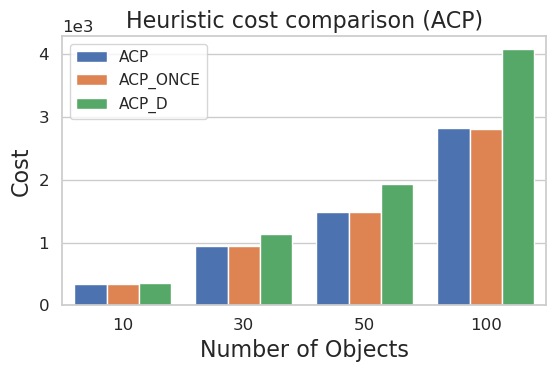

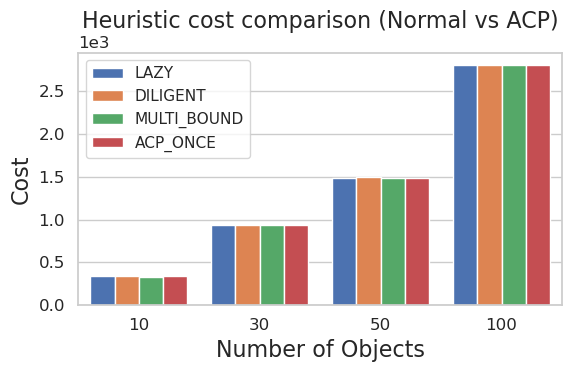

In [14]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res_mean_cost_to_100_ant, x="num_objects", y="cost", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Heuristic cost comparison (ACP)")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res_mean_cost_to_100_non_ant, x="num_objects", y="cost", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Heuristic cost comparison (Normal vs ACP)")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.show()

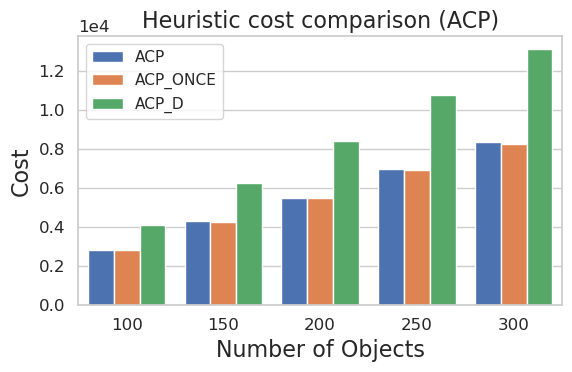

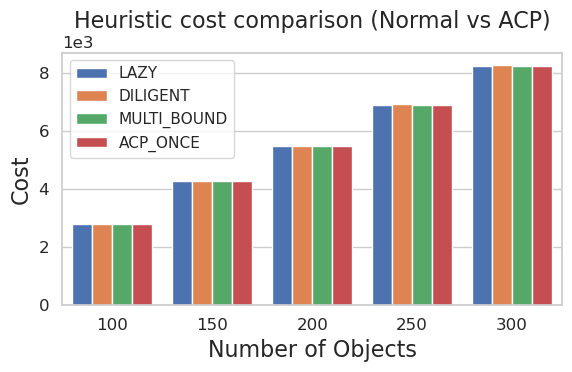

In [15]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res_mean_cost_from_100_ant, x="num_objects", y="cost", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Heuristic cost comparison (ACP)")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res_mean_cost_from_100_non_ant, x="num_objects", y="cost", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Heuristic cost comparison (Normal vs ACP)")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.tight_layout()

plt.show()

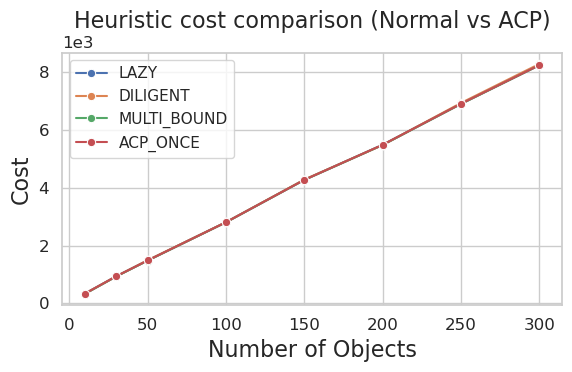

In [16]:
fig, ax = plt.subplots(figsize=figsize)
# ppm_res_mean_cost_non_ant = ppm_res_mean_cost[~ppm_res_mean_cost['heuristic'].isin(['ANTICIPATORY',
#                                                                                      'ANTICIPATORY_ONCE',])]
ax = sns.lineplot(data=ppm_res_mean_cost_non_ant, x="num_objects", y="cost", hue="heuristic", ax=ax, marker='o')
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_title("Heuristic cost comparison (Normal vs ACP)")
plt.tight_layout()
plt.legend(loc='upper left')

plt.show()

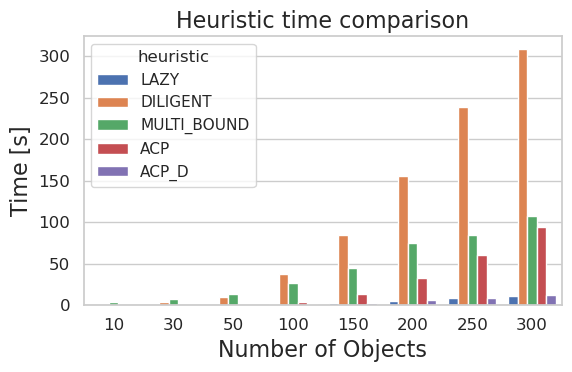

In [17]:
fig, ax = plt.subplots(figsize=figsize)
ppm_res_mean_time_filtered = ppm_res_mean_time[~ppm_res_mean_time['heuristic'].isin(['ACP_ONCE'])].copy()
ppm_res_mean_time_filtered['heuristic'] = ppm_res_mean_time_filtered['heuristic'].cat.remove_unused_categories()
ax = sns.barplot(data=ppm_res_mean_time_filtered, x="num_objects", y="time_taken", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Time [s]")
ax.set_title("Heuristic time comparison")
plt.tight_layout()
plt.show()

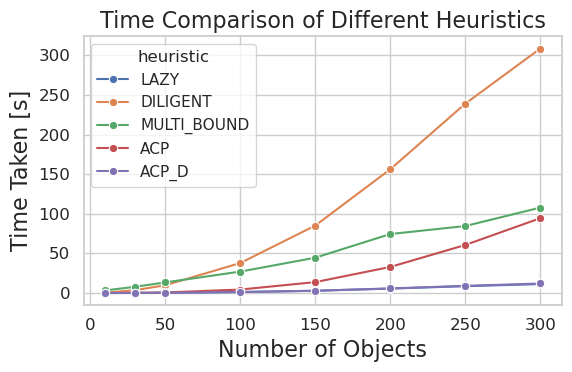

In [18]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.lineplot(data=ppm_res_mean_time_filtered, x="num_objects", y="time_taken", hue="heuristic", ax=ax, marker='o')
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Time Taken [s]")
ax.set_title("Time Comparison of Different Heuristics")
plt.tight_layout()
plt.show()

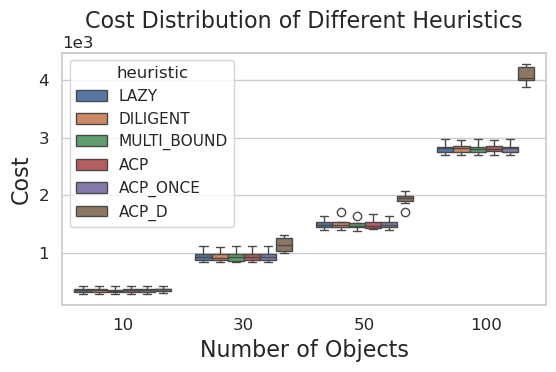

In [19]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.boxplot(data=ppm_res[ppm_res['num_objects'] <= 100], x="num_objects", y="cost", hue="heuristic", ax=ax)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_title("Cost Distribution of Different Heuristics")
plt.tight_layout()
plt.show()

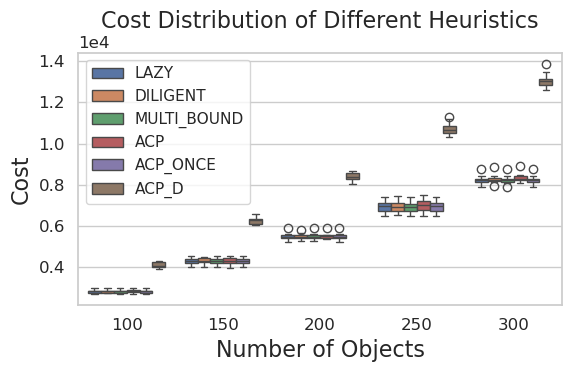

In [20]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.boxplot(data=ppm_res[ppm_res['num_objects'] >= 100], x="num_objects", y="cost", hue="heuristic", ax=ax)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_title("Cost Distribution of Different Heuristics")
plt.tight_layout()
plt.legend(loc='upper left')
plt.show()

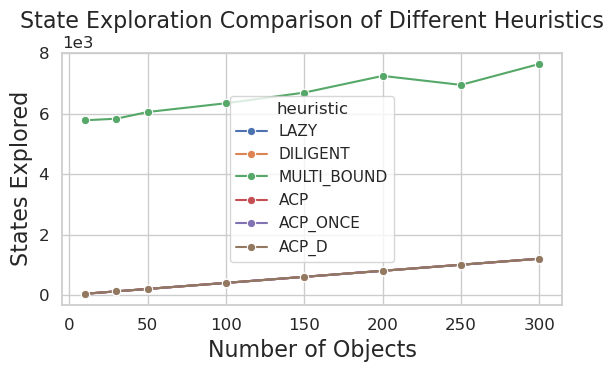

In [21]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.lineplot(data=ppm_res_mean_states, x="num_objects", y="states_explored", hue="heuristic", ax=ax, marker='o')
ax.set_xlabel("Number of Objects")
ax.set_ylabel("States Explored")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_title("State Exploration Comparison of Different Heuristics")
plt.tight_layout()
plt.show()

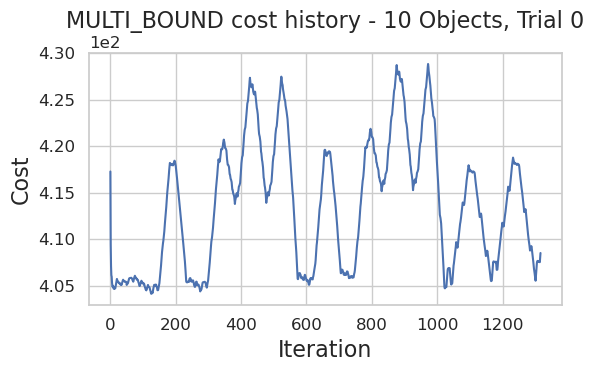

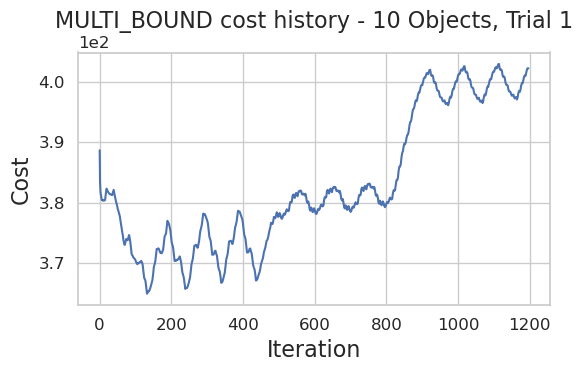

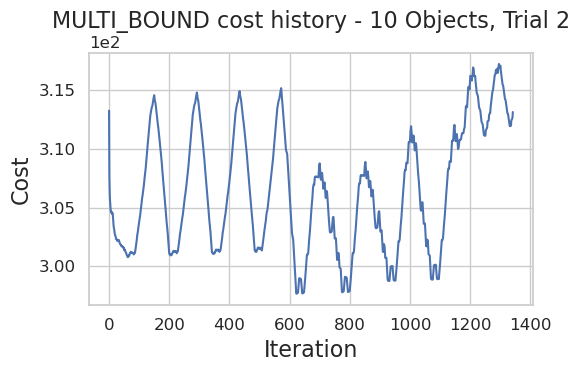

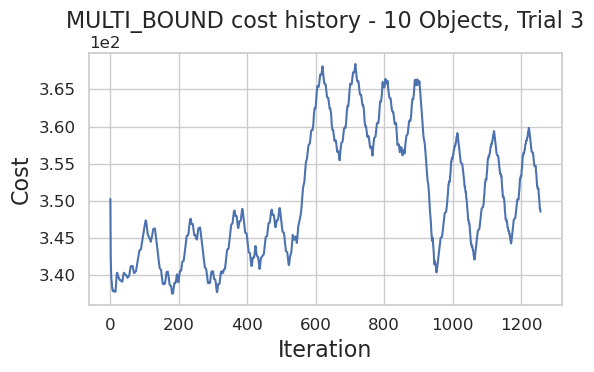

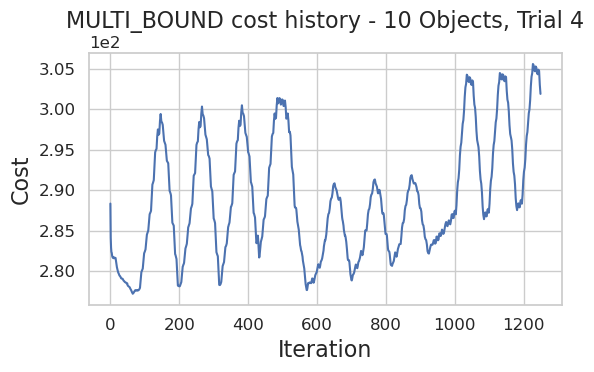

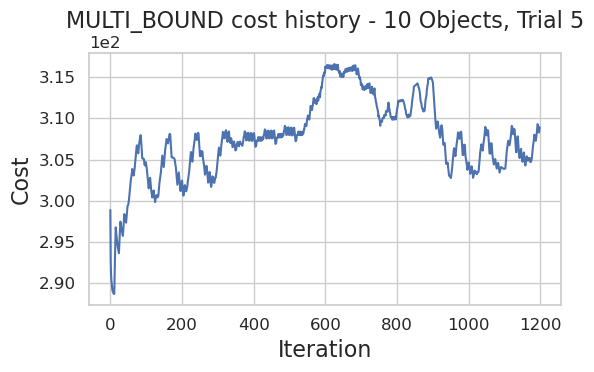

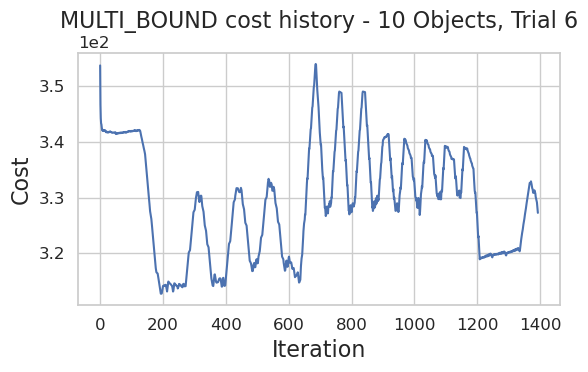

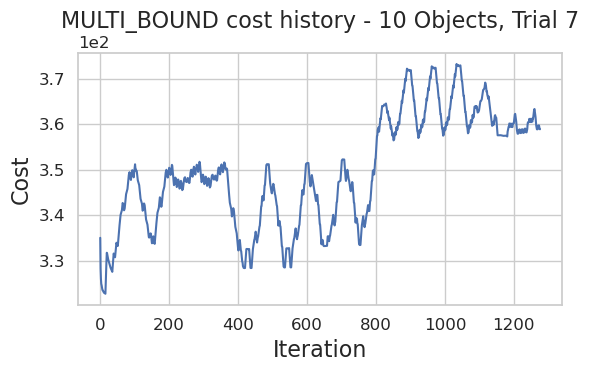

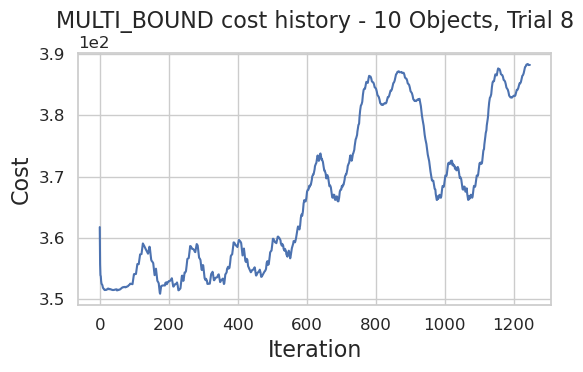

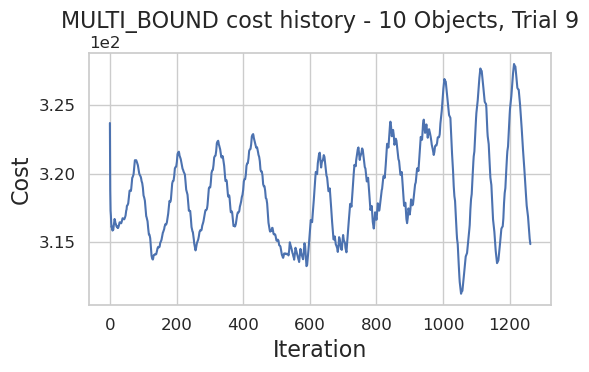

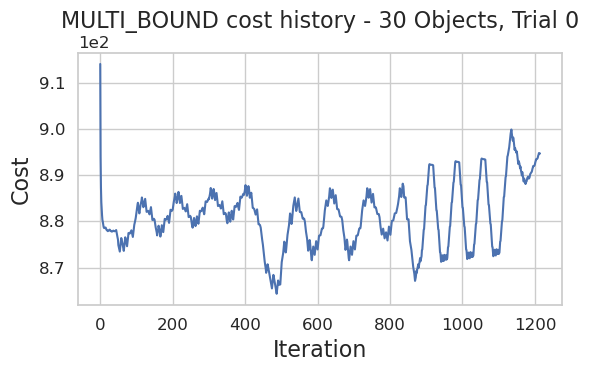

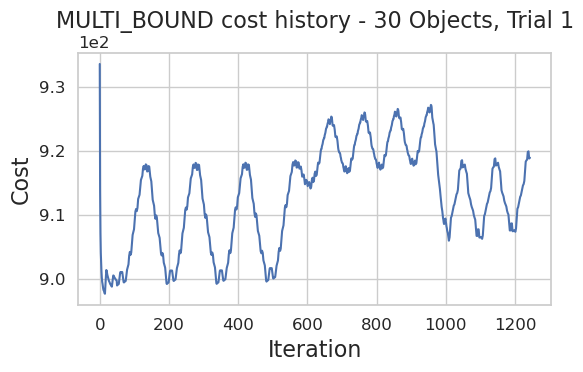

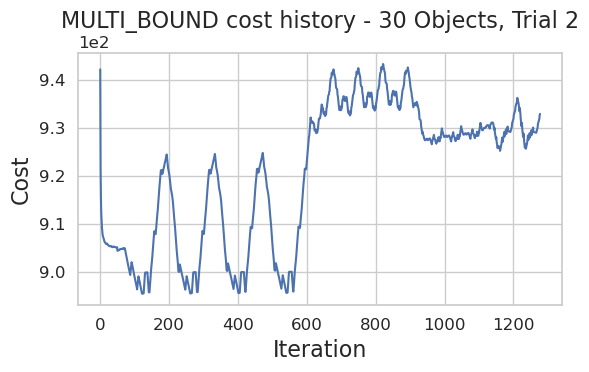

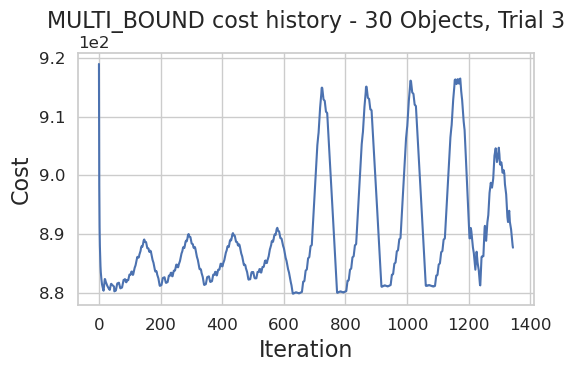

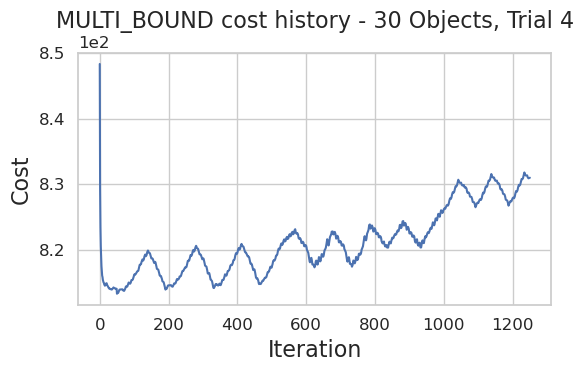

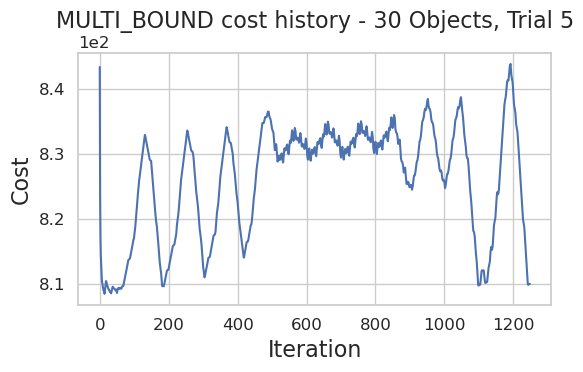

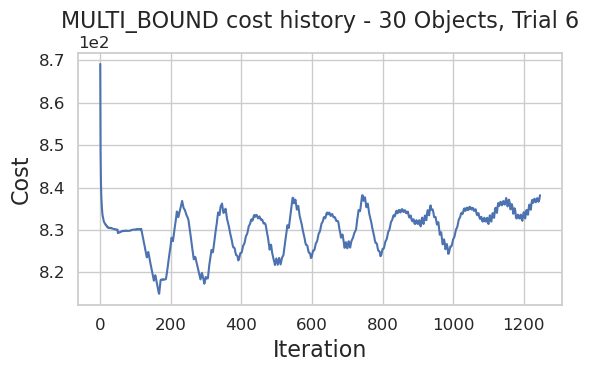

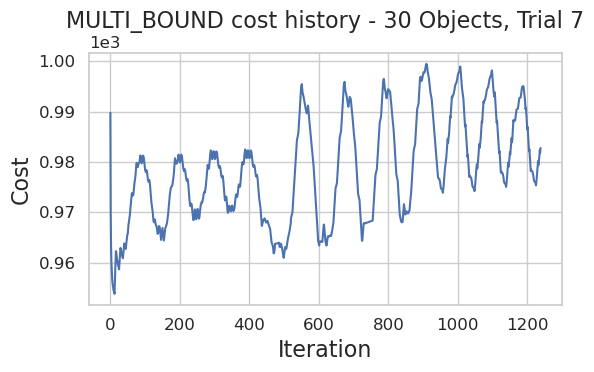

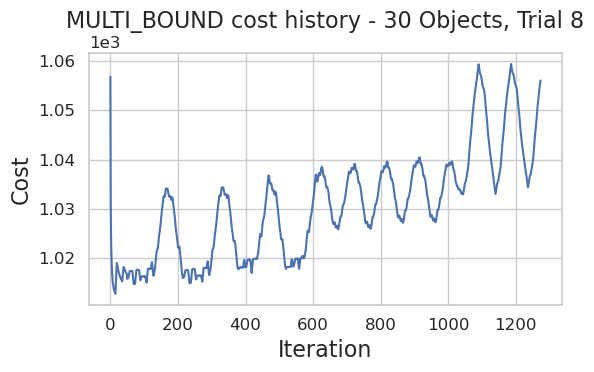

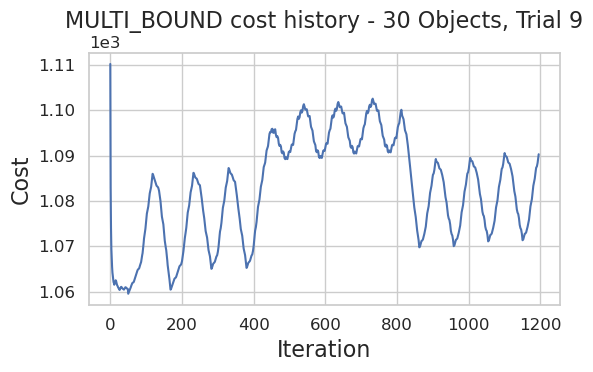

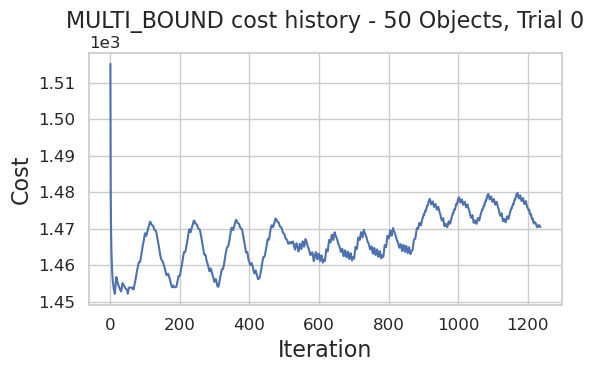

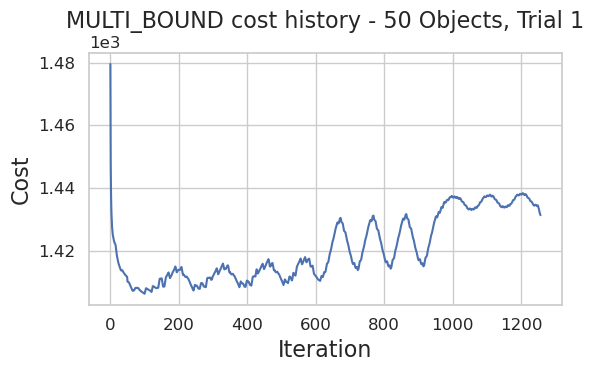

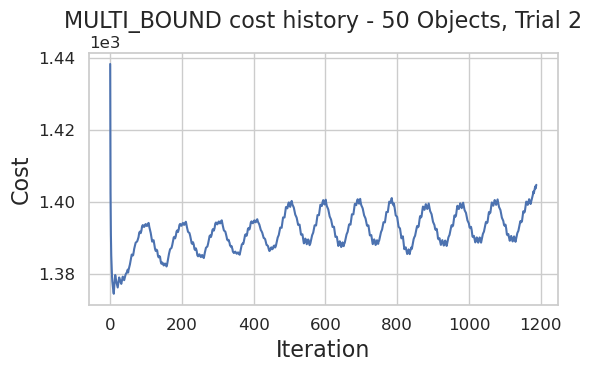

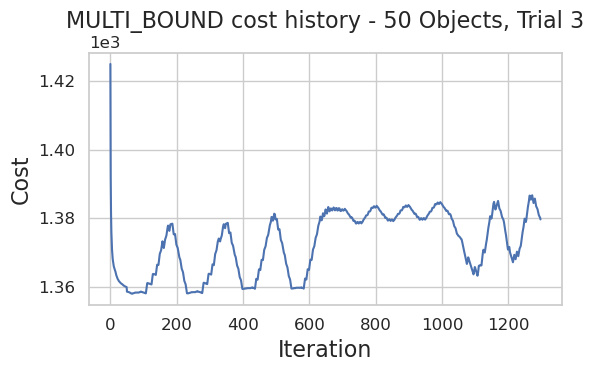

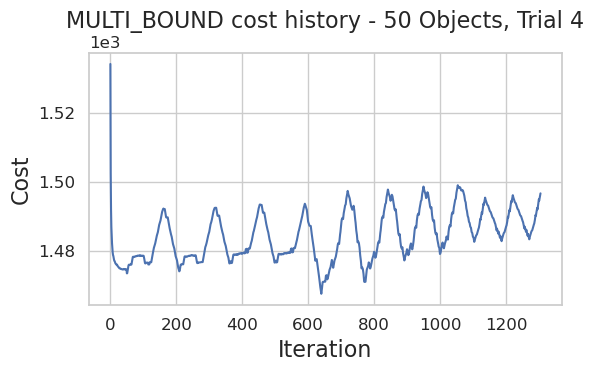

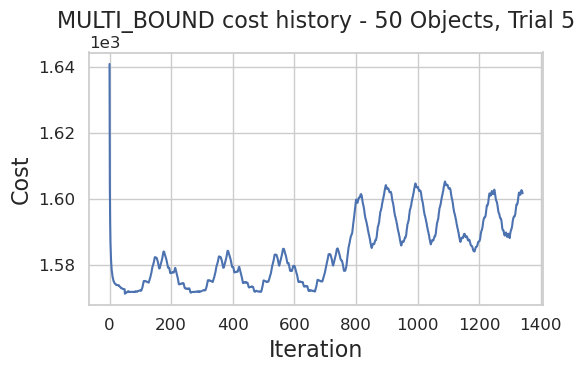

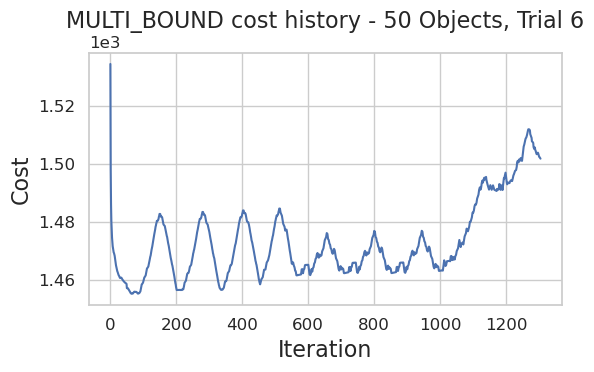

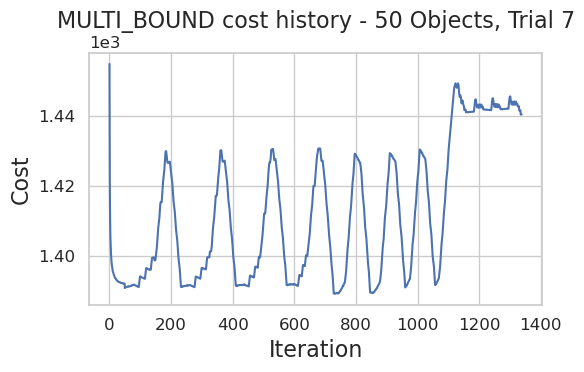

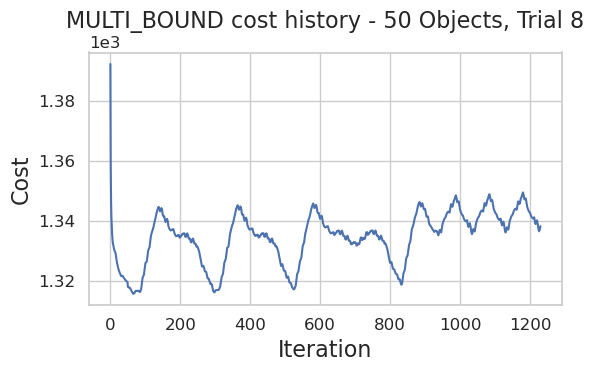

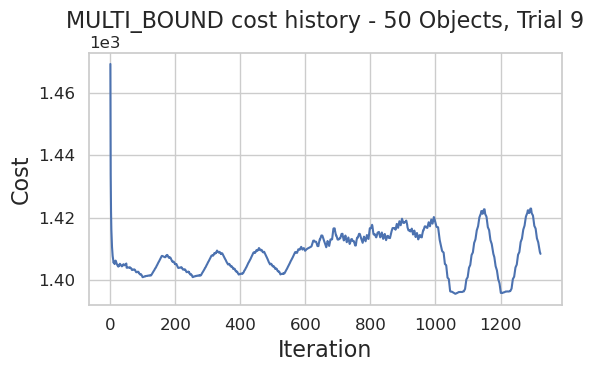

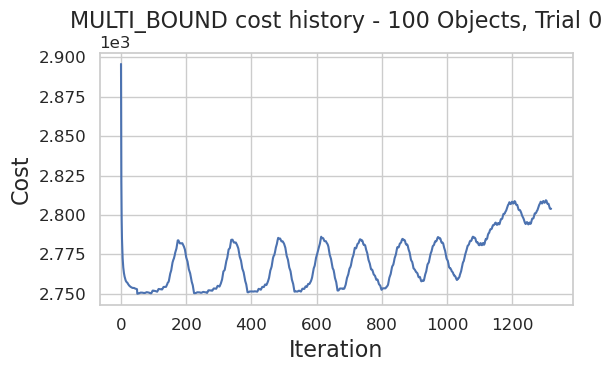

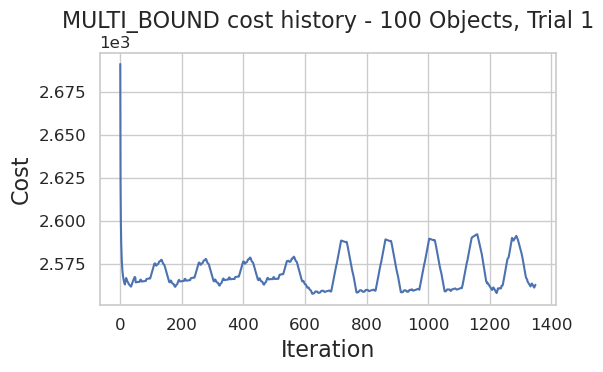

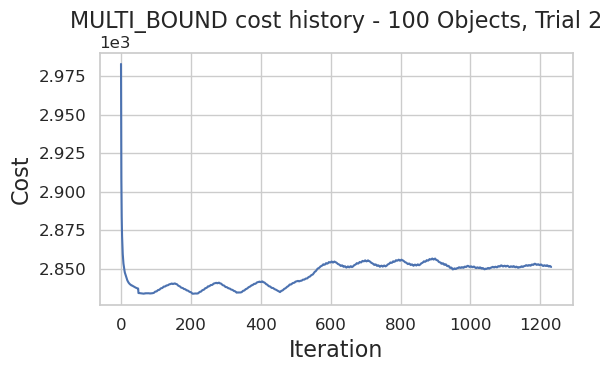

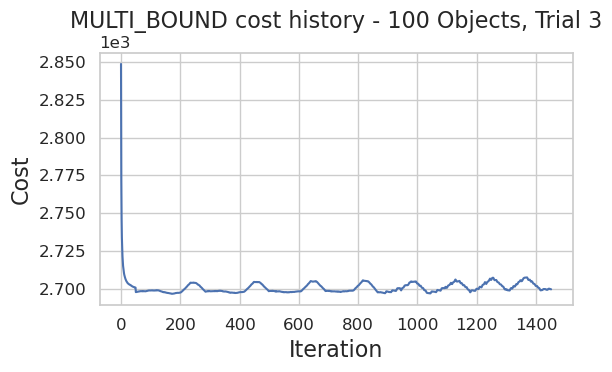

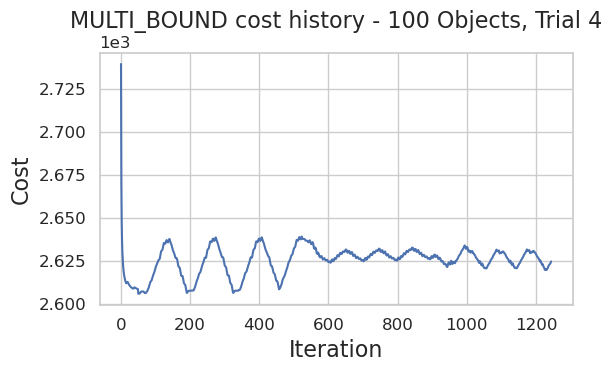

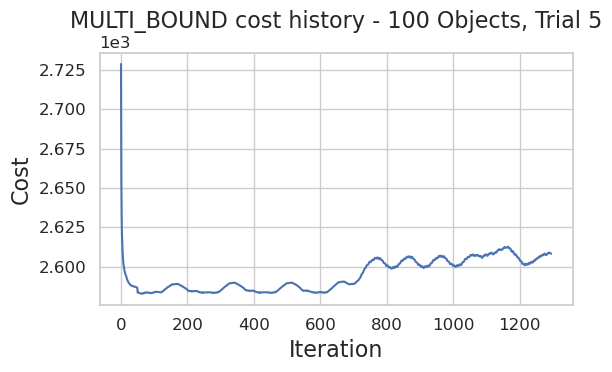

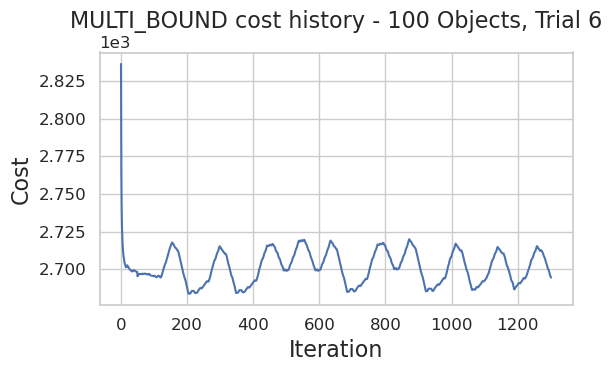

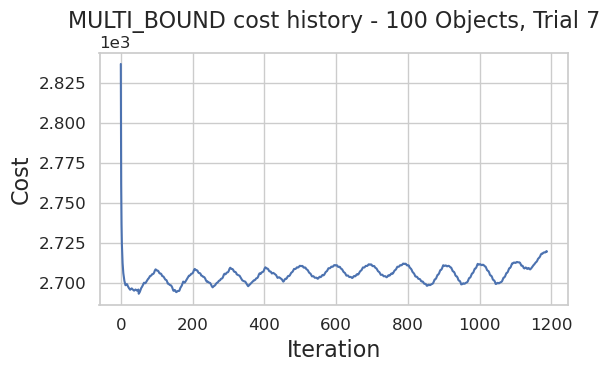

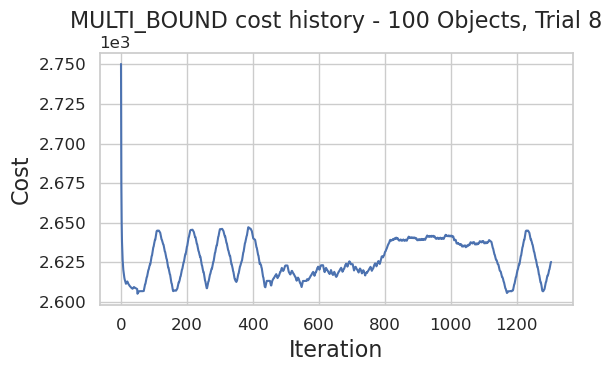

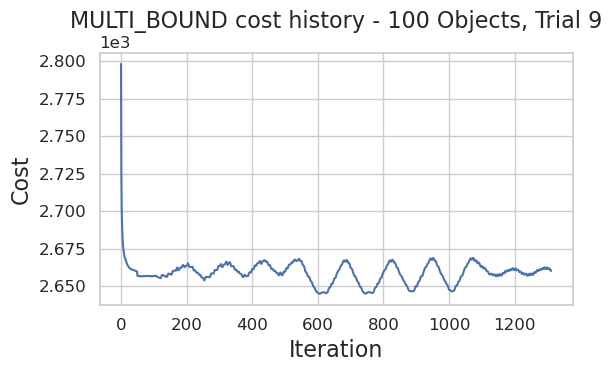

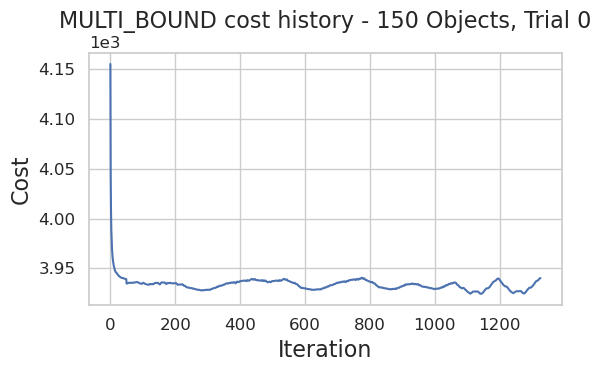

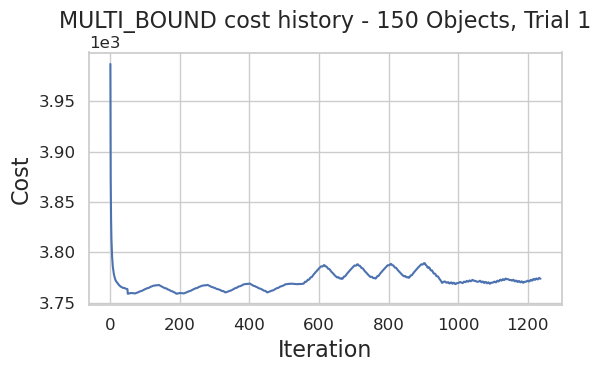

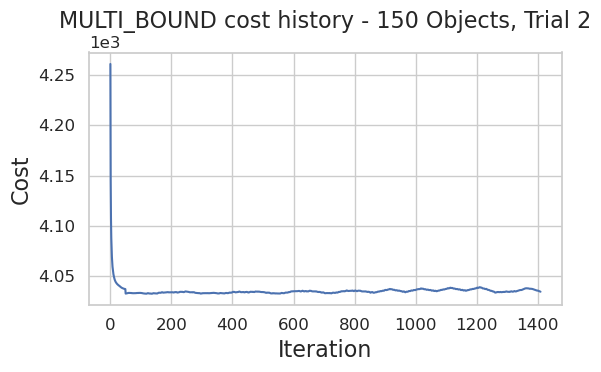

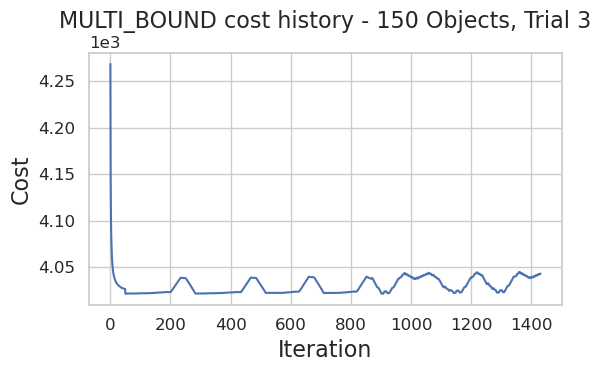

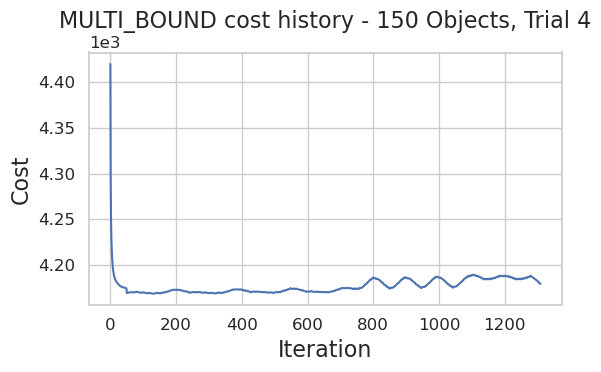

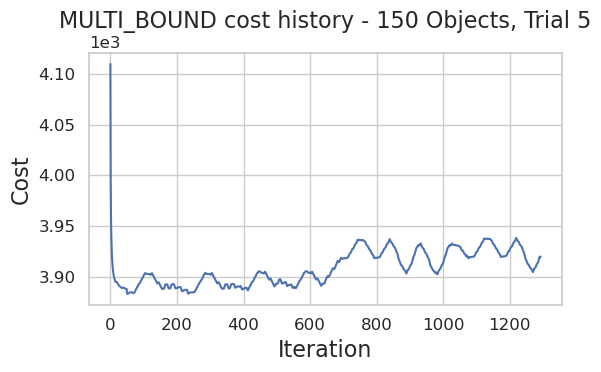

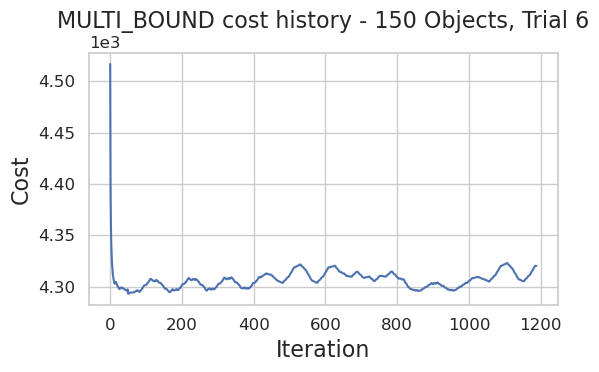

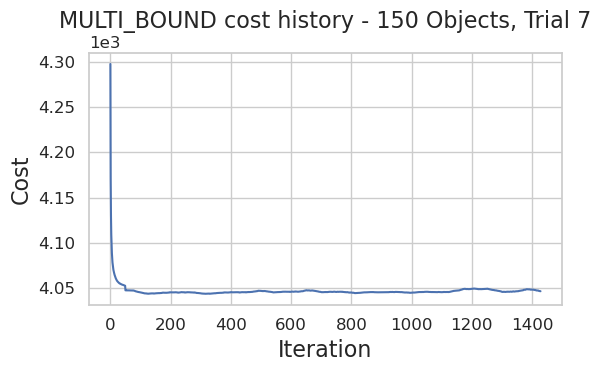

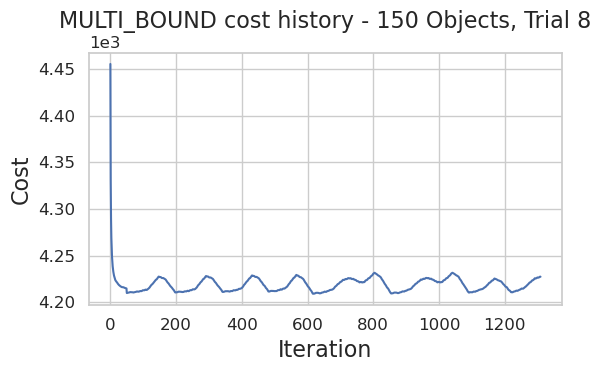

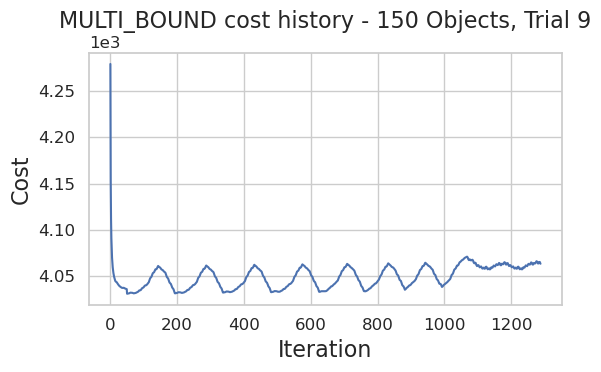

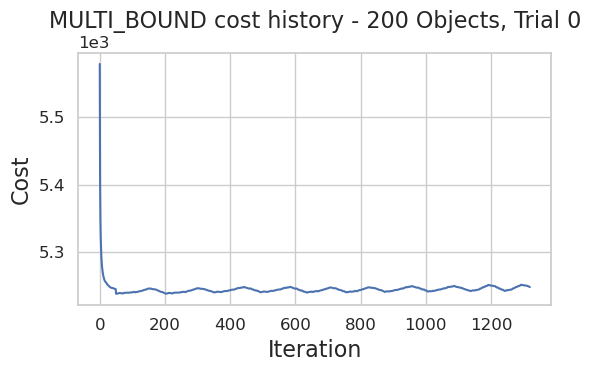

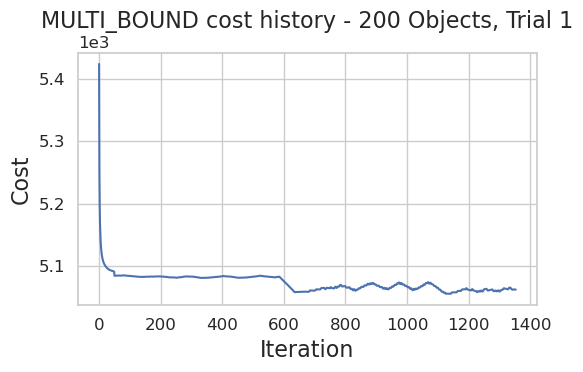

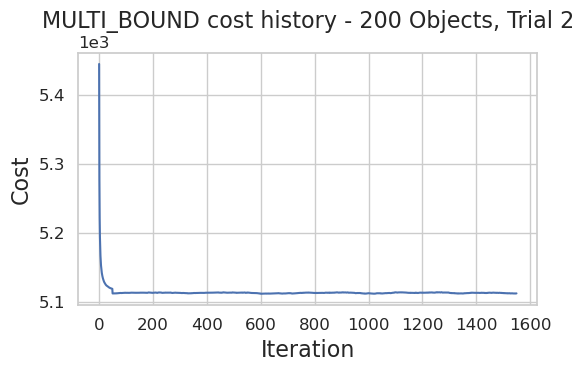

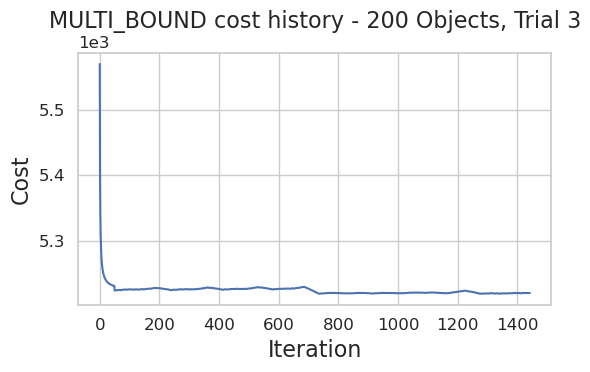

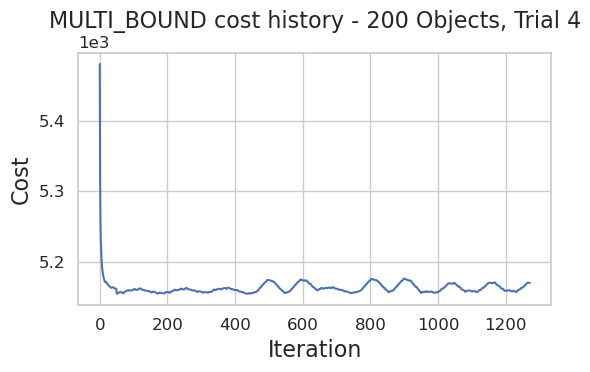

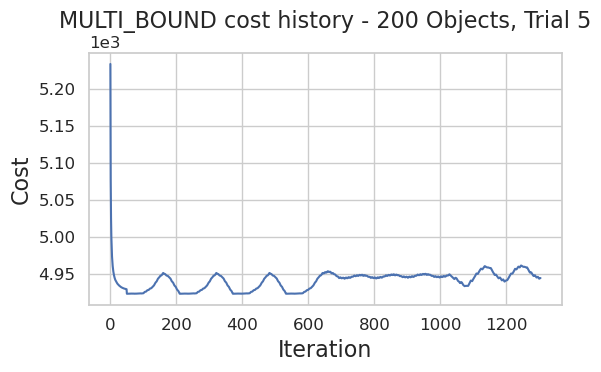

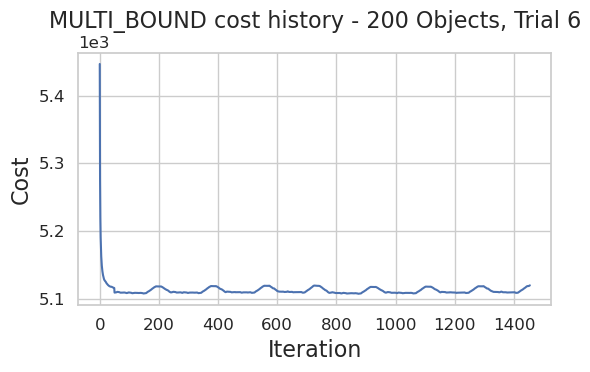

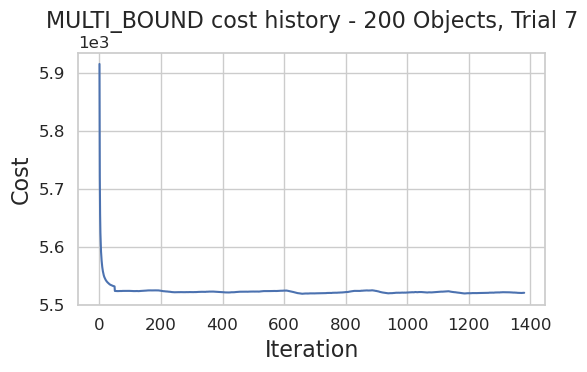

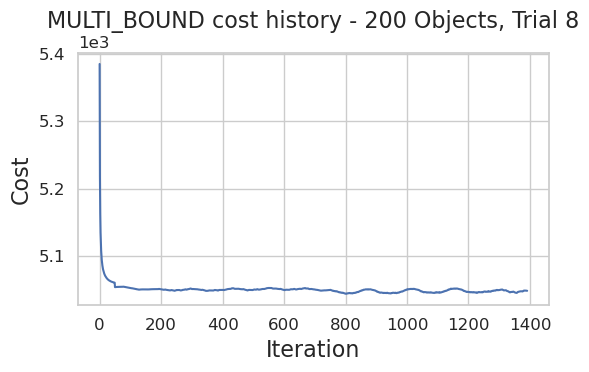

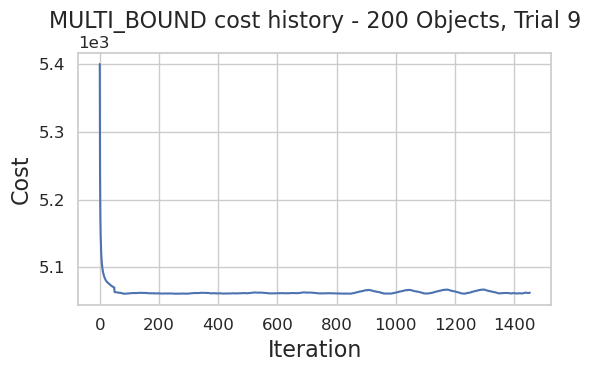

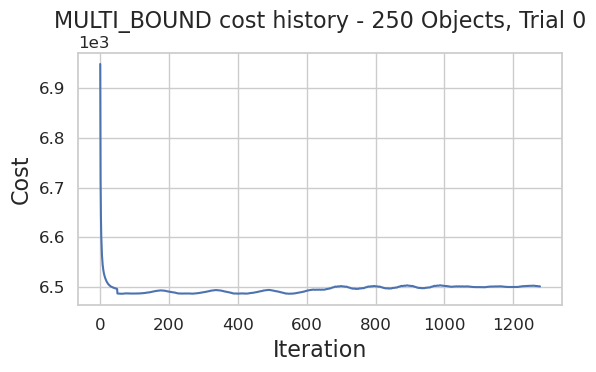

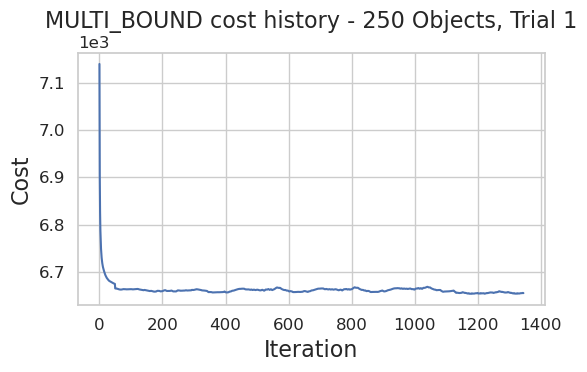

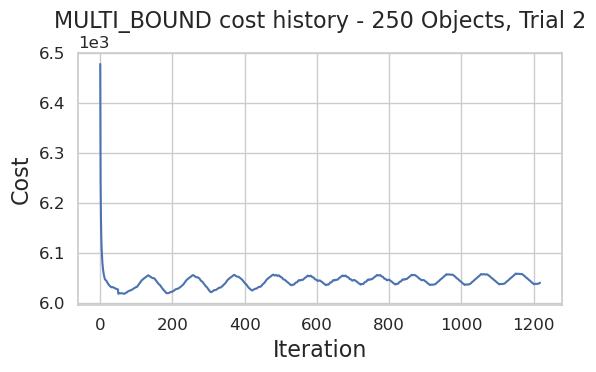

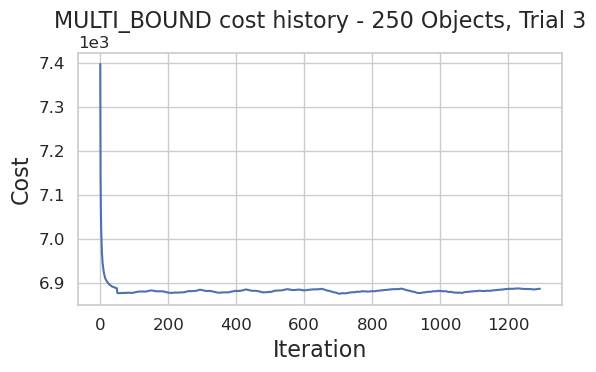

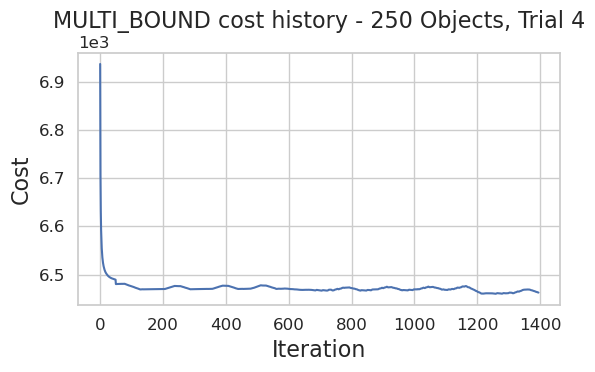

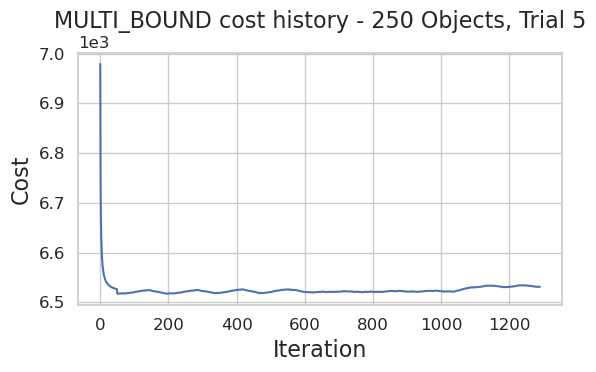

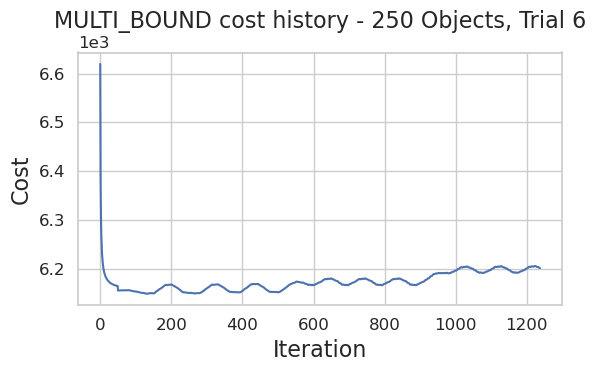

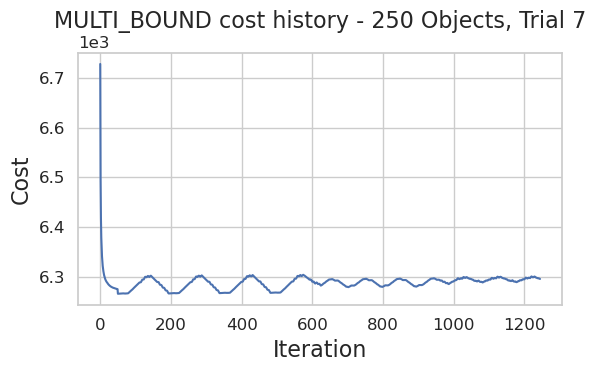

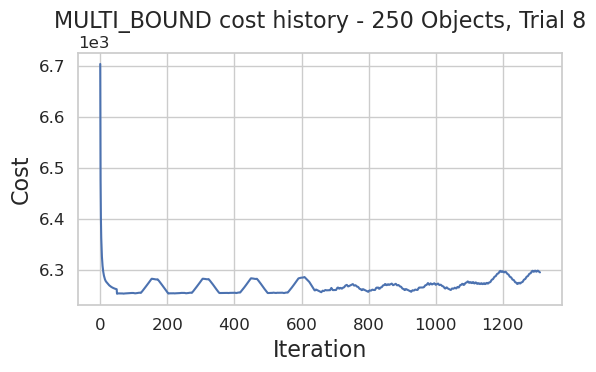

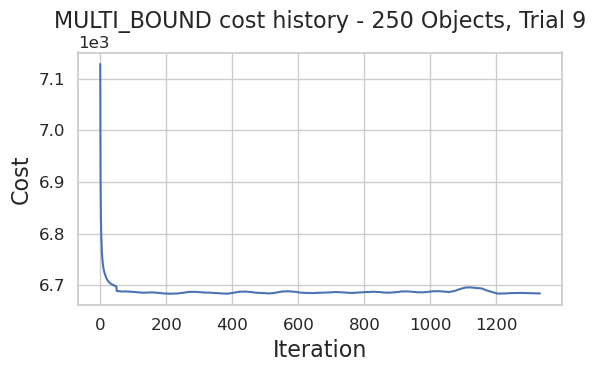

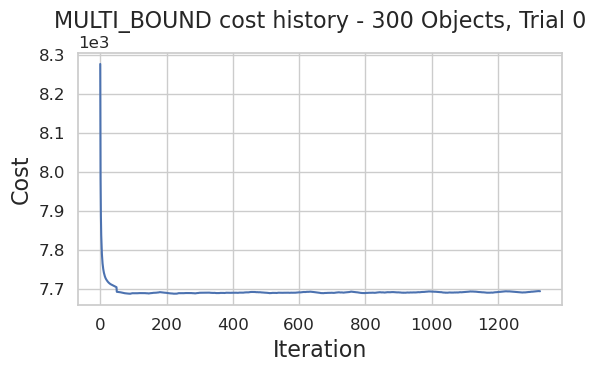

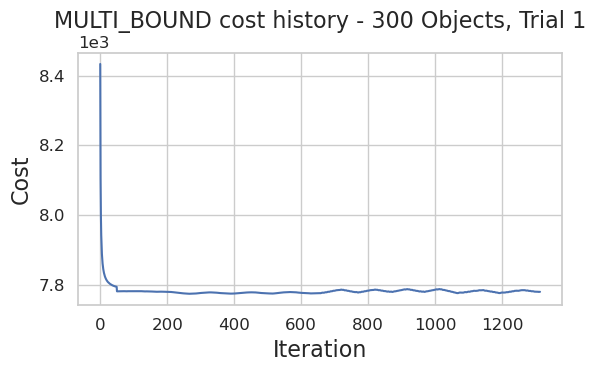

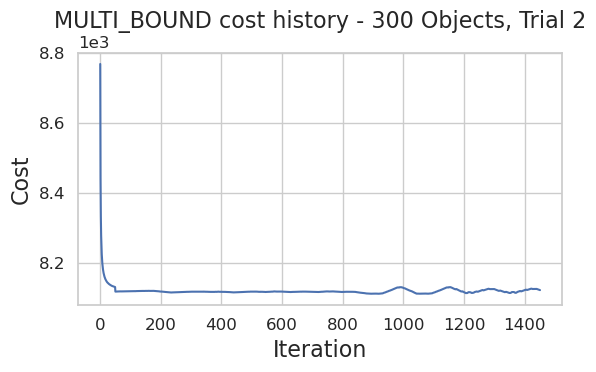

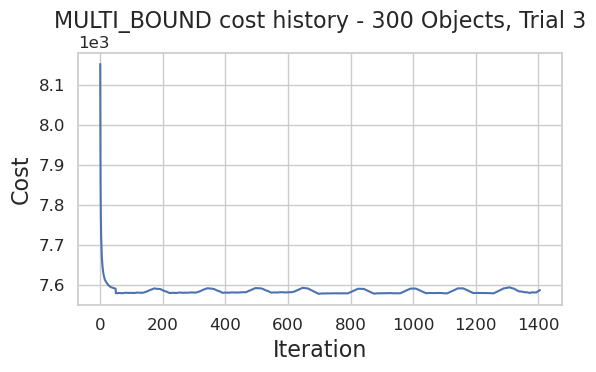

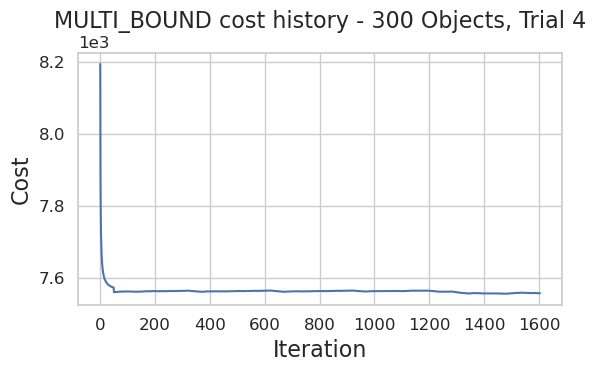

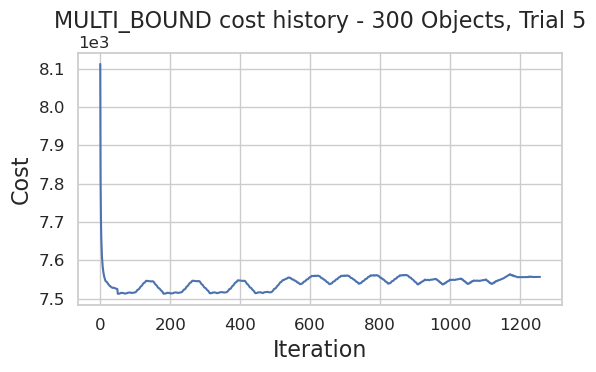

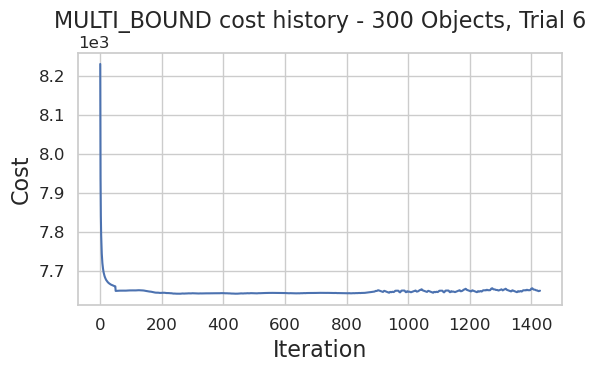

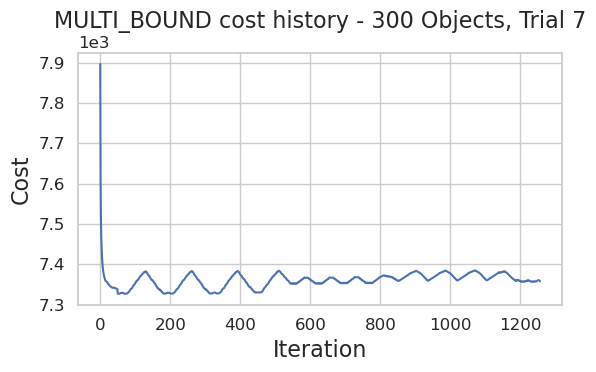

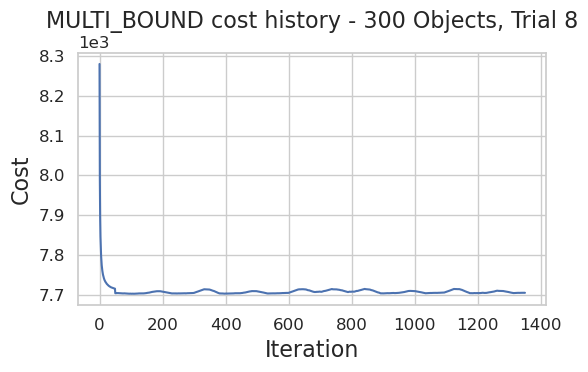

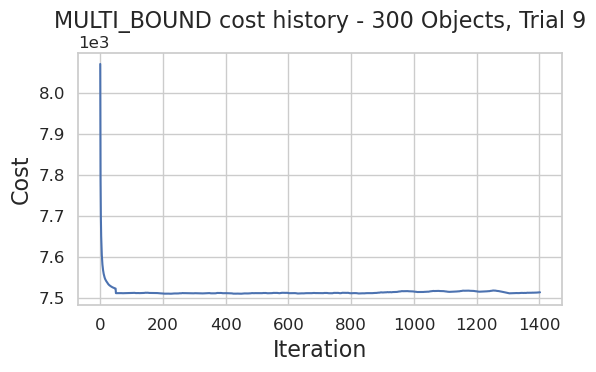

In [22]:
mb_cost_hist_df = pd.read_csv(f"{results_path}/mb_planner_comp_results_all_detailed.csv")
num_objects_list = mb_cost_hist_df['num_objects'].unique()
num_objects_list.sort()
trials = mb_cost_hist_df['trial_num'].unique()
trials.sort()

window_size = 50
for num_objects in num_objects_list:
    for trial in trials:
        subset = mb_cost_hist_df[(mb_cost_hist_df['num_objects'] == num_objects) & (mb_cost_hist_df['trial_num'] == trial)]
        if subset.empty:
            continue

        subset['smoothed_cost'] = subset['cost'].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).mean()
        )

        plt.figure(figsize=figsize)
        sns.lineplot(data=subset, x="iter", y="smoothed_cost")
        plt.xlabel("Iteration")
        plt.ylabel("Cost")
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        plt.title(f"MULTI_BOUND cost history - {num_objects} Objects, Trial {trial}")
        plt.tight_layout()
        # plt.savefig(f"../../../../../new_plots/mb_costs/mb_cost_history_num_objects_{num_objects}_trial_{trial}.png",
                    # bbox_inches='tight', dpi=150)
        plt.show()